# Model Validation and Forecasting Protocol Audit

This notebook audits whether the earlier forecasting results are valid before they are used in any trustworthiness ranking. The central question is whether Naive persistence genuinely outperforms the neural models, or whether the apparent underperformance is caused by an implementation, alignment, scaling, target, or forecasting-protocol error.

No model should be promoted into the trustworthiness ranking until this audit passes.

In [1]:
from pathlib import Path
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Add, Dense, Dropout, Embedding, GlobalAveragePooling1D, Input, Layer, LayerNormalization, MultiHeadAttention
from tensorflow.keras.models import Model, Sequential

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import mae, rmse, mape, smape

warnings.filterwarnings("ignore")
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()
pd.set_option("display.float_format", "{:.6f}".format)

## 1. Dataset and Split Verification

In [2]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"
raw_df = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(raw_df)
target = df_daily["Close"].asfreq("D").dropna().rename("Close")

split_idx = int(len(target) * 0.8)
train = target.iloc[:split_idx]
test = target.iloc[split_idx:]
y_test = test.copy()

train_test_overlap = train.index.intersection(test.index)

split_report = pd.DataFrame(
    {
        "Item": [
            "Complete series date range",
            "Training date range",
            "Test date range",
            "Training length",
            "Test length",
            "Train/test overlap",
        ],
        "Value": [
            f"{target.index.min()} to {target.index.max()}",
            f"{train.index.min()} to {train.index.max()}",
            f"{test.index.min()} to {test.index.max()}",
            len(train),
            len(test),
            len(train_test_overlap) > 0,
        ],
    }
)
split_report

,Item,Value
0,Complete series date range,2012-01-01 00:00:00+00:00 to 2026-07-07 00:00:...
1,Training date range,2012-01-01 00:00:00+00:00 to 2023-08-11 00:00:...
2,Test date range,2023-08-12 00:00:00+00:00 to 2026-07-07 00:00:...
3,Training length,4241
4,Test length,1061
5,Train/test overlap,False


## 2. Forecast Horizon Definition

In [3]:
FORECAST_HORIZON = 1
LOOKBACK_LSTM = 30
LOOKBACK_IMPROVED_LSTM = 60
LOOKBACK_TRANSFORMER = 30

protocol_definition = pd.DataFrame(
    {
        "Protocol": ["A", "B"],
        "Name": ["Rolling one-step-ahead", "Recursive multi-step"],
        "Information available at each test date": [
            "All observed actual values up to the previous day are available.",
            "Only the final training window is available; future inputs are model predictions.",
        ],
        "Use of actual test values as future inputs": ["Allowed after each date is observed", "Not allowed"],
    }
)
protocol_definition

,Protocol,Name,Information available at each test date,Use of actual test values as future inputs
0,A,Rolling one-step-ahead,All observed actual values up to the previous ...,Allowed after each date is observed
1,B,Recursive multi-step,Only the final training window is available; f...,Not allowed


## 3. Sequence and Target Alignment

In [4]:
def create_sequences(values, index, lookback):
    X, y, rows = [], [], []
    for i in range(lookback, len(values)):
        X.append(values[i - lookback : i])
        y.append(values[i])
        rows.append(
            {
                "input_window_start": index[i - lookback],
                "input_window_end": index[i - 1],
                "target_date": index[i],
                "last_input_value": float(values[i - 1, 0]),
                "target_value": float(values[i, 0]),
            }
        )
    return np.array(X), np.array(y), pd.DataFrame(rows)

scaler = MinMaxScaler(feature_range=(0, 1))
train_values = train.to_numpy().reshape(-1, 1)
test_values = test.to_numpy().reshape(-1, 1)
train_scaled = scaler.fit_transform(train_values)
test_scaled = scaler.transform(test_values)

X_train_lstm, y_train_lstm, train_sequence_map = create_sequences(train_scaled, train.index, LOOKBACK_LSTM)
combined_test_scaled = np.vstack([train_scaled[-LOOKBACK_LSTM:], test_scaled])
combined_test_index = train.index[-LOOKBACK_LSTM:].append(test.index)
X_test_lstm, y_test_lstm_scaled, test_sequence_map = create_sequences(combined_test_scaled, combined_test_index, LOOKBACK_LSTM)

test_sequence_map["sequence_ends_then_predicts_next_day"] = test_sequence_map["target_date"] == test_sequence_map["input_window_end"] + pd.Timedelta(days=1)
test_sequence_map.head(10)

,input_window_start,input_window_end,target_date,last_input_value,target_value,sequence_ends_then_predicts_next_day
0,2023-07-13 00:00:00+00:00,2023-08-11 00:00:00+00:00,2023-08-12 00:00:00+00:00,0.435110,0.435362,True
1,2023-07-14 00:00:00+00:00,2023-08-12 00:00:00+00:00,2023-08-13 00:00:00+00:00,0.435362,0.433423,True
2,2023-07-15 00:00:00+00:00,2023-08-13 00:00:00+00:00,2023-08-14 00:00:00+00:00,0.433423,0.435258,True
3,2023-07-16 00:00:00+00:00,2023-08-14 00:00:00+00:00,2023-08-15 00:00:00+00:00,0.435258,0.431765,True
4,2023-07-17 00:00:00+00:00,2023-08-15 00:00:00+00:00,2023-08-16 00:00:00+00:00,0.431765,0.424793,True
5,2023-07-18 00:00:00+00:00,2023-08-16 00:00:00+00:00,2023-08-17 00:00:00+00:00,0.424793,0.394314,True
6,2023-07-19 00:00:00+00:00,2023-08-17 00:00:00+00:00,2023-08-18 00:00:00+00:00,0.394314,0.385565,True
7,2023-07-20 00:00:00+00:00,2023-08-18 00:00:00+00:00,2023-08-19 00:00:00+00:00,0.385565,0.386246,True
8,2023-07-21 00:00:00+00:00,2023-08-19 00:00:00+00:00,2023-08-20 00:00:00+00:00,0.386246,0.387652,True
9,2023-07-22 00:00:00+00:00,2023-08-20 00:00:00+00:00,2023-08-21 00:00:00+00:00,0.387652,0.386661,True


In [5]:
def alignment_checks(name, forecast, y_true):
    return {
        "Model": name,
        "Forecast length equals y_test length": len(forecast) == len(y_true),
        "Forecast index exactly equals y_test index": forecast.index.equals(y_true.index),
        "No missing values": not forecast.isna().any(),
        "No duplicated timestamps": not forecast.index.duplicated().any(),
        "No shifted-target symptom vs y[t+1]": not forecast.corr(y_true.shift(-1)) > forecast.corr(y_true),
    }

# Populated after forecasts are recreated below.
alignment_audit_rows = []

## 4. Scaling and Inverse-Scaling Audit

In [6]:
roundtrip_train = scaler.inverse_transform(scaler.transform(train_values)).ravel()
roundtrip_test = scaler.inverse_transform(scaler.transform(test_values)).ravel()

scaling_audit = pd.DataFrame(
    {
        "Check": [
            "Scaler fitted only on training data",
            "scaler.data_min_",
            "scaler.data_max_",
            "Train scaled min/max",
            "Test scaled min/max",
            "Train inverse-transform roundtrip OK",
            "Test inverse-transform roundtrip OK",
            "Test values exceed training scaling range",
        ],
        "Result": [
            True,
            scaler.data_min_[0],
            scaler.data_max_[0],
            f"{train_scaled.min():.6f} to {train_scaled.max():.6f}",
            f"{test_scaled.min():.6f} to {test_scaled.max():.6f}",
            np.allclose(roundtrip_train, train_values.ravel()),
            np.allclose(roundtrip_test, test_values.ravel()),
            bool((test_scaled < 0).any() or (test_scaled > 1).any()),
        ],
    }
)
scaling_audit

,Check,Result
0,Scaler fitted only on training data,True
1,scaler.data_min_,4.230000
2,scaler.data_max_,67559.000000
3,Train scaled min/max,0.000000 to 1.000000
4,Test scaled min/max,0.372302 to 1.846261
5,Train inverse-transform roundtrip OK,True
6,Test inverse-transform roundtrip OK,True
7,Test values exceed training scaling range,True


## 5. Baseline Audit

In [7]:
naive_forecast = target.shift(1).reindex(test.index).rename("Naive")
constant_last_train_forecast = pd.Series(train.iloc[-1], index=test.index, name="Constant Last Train Value")
moving_average_forecast = target.shift(1).rolling(window=7).mean().reindex(test.index).rename("7-Day Moving Average")

naive_expected = target.shift(1).reindex(test.index)
ma_expected = target.shift(1).rolling(window=7).mean().reindex(test.index)

baseline_audit = pd.DataFrame(
    {
        "Check": [
            "Naive equals actual[t-1]",
            "Naive differs from constant last-training-value forecast",
            "Moving average uses preceding seven observations only",
            "Moving average does not include target day",
        ],
        "Result": [
            naive_forecast.equals(naive_expected.rename("Naive")),
            not naive_forecast.equals(constant_last_train_forecast.rename("Naive")),
            moving_average_forecast.equals(ma_expected.rename("7-Day Moving Average")),
            moving_average_forecast.iloc[1:].ne(target.reindex(test.index).iloc[1:]).any(),
        ],
    }
)
baseline_audit

,Check,Result
0,Naive equals actual[t-1],True
1,Naive differs from constant last-training-valu...,True
2,Moving average uses preceding seven observatio...,True
3,Moving average does not include target day,True


## 6. LSTM Audit

In [8]:
def build_original_lstm(lookback=30):
    model = Sequential([
        Input(shape=(lookback, 1)),
        tf.keras.layers.LSTM(
            32,
            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42),
            recurrent_initializer=tf.keras.initializers.Orthogonal(seed=42),
        ),
        Dense(1, kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42)),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

lstm_model = build_original_lstm(LOOKBACK_LSTM)
lstm_callback = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
lstm_history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[lstm_callback],
    shuffle=False,
    verbose=0,
)
lstm_predictions_scaled = lstm_model.predict(X_test_lstm, verbose=0)
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled).ravel()
lstm_forecast = pd.Series(lstm_predictions, index=test.index, name="Original LSTM")

lstm_audit_table = pd.DataFrame(
    {
        "Check": [
            "Model input shape",
            "Model output shape",
            "X_train shape",
            "y_train shape",
            "X_test shape",
            "y_test shape",
            "Output layer activation is linear",
            "y_train is next value after each input window",
            "Final training loss",
            "Final validation loss",
        ],
        "Result": [
            str(lstm_model.input_shape),
            str(lstm_model.output_shape),
            str(X_train_lstm.shape),
            str(y_train_lstm.shape),
            str(X_test_lstm.shape),
            str(y_test_lstm_scaled.shape),
            lstm_model.layers[-1].activation.__name__ == "linear",
            bool((train_sequence_map["target_date"] == train_sequence_map["input_window_end"] + pd.Timedelta(days=1)).all()),
            lstm_history.history["loss"][-1],
            lstm_history.history["val_loss"][-1],
        ],
    }
)
lstm_model.summary()
lstm_audit_table

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,157 (51.40 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,772 (34.27 KB)

,Check,Result
0,Model input shape,"(None, 30, 1)"
1,Model output shape,"(None, 1)"
2,X_train shape,"(4211, 30, 1)"
3,y_train shape,"(4211, 1)"
4,X_test shape,"(1061, 30, 1)"
5,y_test shape,"(1061, 1)"
6,Output layer activation is linear,True
7,y_train is next value after each input window,True
8,Final training loss,0.001151
9,Final validation loss,0.001670


In [9]:
def prediction_diagnostics(name, forecast, actual):
    aligned = pd.concat([actual.rename("actual"), forecast.rename("prediction")], axis=1).dropna()
    return pd.Series(
        {
            "prediction_min": aligned["prediction"].min(),
            "prediction_max": aligned["prediction"].max(),
            "prediction_mean": aligned["prediction"].mean(),
            "prediction_std": aligned["prediction"].std(),
            "actual_min": aligned["actual"].min(),
            "actual_max": aligned["actual"].max(),
            "actual_mean": aligned["actual"].mean(),
            "actual_std": aligned["actual"].std(),
            "prediction_daily_change_std": aligned["prediction"].diff().std(),
            "actual_daily_change_std": aligned["actual"].diff().std(),
            "correlation_with_actual": aligned["prediction"].corr(aligned["actual"]),
            "correlation_with_previous_day_actual": aligned["prediction"].corr(target.shift(1).reindex(aligned.index)),
            "percentage_unique_predictions": 100 * aligned["prediction"].nunique() / len(aligned),
        },
        name=name,
    )

lstm_first_20 = pd.concat([y_test.rename("Actual"), lstm_forecast.rename("Original LSTM")], axis=1).head(20)
lstm_diagnostics = prediction_diagnostics("Original LSTM", lstm_forecast, y_test)

display(lstm_first_20)
lstm_diagnostics.to_frame().T

,Actual,Original LSTM
Timestamp,,
2023-08-12 00:00:00+00:00,29415.000000,30765.283203
2023-08-13 00:00:00+00:00,29284.000000,30782.978516
2023-08-14 00:00:00+00:00,29408.000000,30776.714844
2023-08-15 00:00:00+00:00,29172.000000,30784.785156
2023-08-16 00:00:00+00:00,28701.000000,30756.890625
2023-08-17 00:00:00+00:00,26642.000000,30657.730469
2023-08-18 00:00:00+00:00,26051.000000,30255.291016
2023-08-19 00:00:00+00:00,26097.000000,29768.927734
2023-08-20 00:00:00+00:00,26192.000000,29321.630859


,prediction_min,prediction_max,prediction_mean,prediction_std,actual_min,actual_max,actual_mean,actual_std,prediction_daily_change_std,actual_daily_change_std,correlation_with_actual,correlation_with_previous_day_actual,percentage_unique_predictions
Original LSTM,27382.261719,102936.078125,69637.007812,20468.076172,25155.000000,124728.000000,75171.105617,25564.279690,445.506256,1855.088666,0.990712,0.993004,100.000000


## 7. Transformer Audit

In [10]:
class PositionalEmbedding(Layer):
    def __init__(self, lookback, d_model, **kwargs):
        super().__init__(**kwargs)
        self.lookback = lookback
        self.d_model = d_model
        self.embedding = Embedding(input_dim=lookback, output_dim=d_model, embeddings_initializer=tf.keras.initializers.RandomUniform(seed=42))

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.lookback, delta=1)
        position_embedding = self.embedding(positions)
        return inputs + tf.expand_dims(position_embedding, axis=0)

    def get_config(self):
        config = super().get_config()
        config.update({"lookback": self.lookback, "d_model": self.d_model})
        return config


def build_corrected_transformer(lookback=30, d_model=64, num_heads=4, ff_dim=128, dropout=0.1, use_positional_embedding=True):
    inputs = Input(shape=(lookback, 1), name="price_window")
    x = Dense(d_model, name="input_projection", kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42))(inputs)

    if use_positional_embedding:
        x = PositionalEmbedding(lookback=lookback, d_model=d_model, name="positional_embedding")(x)

    attention_output = MultiHeadAttention(key_dim=d_model // num_heads, num_heads=num_heads, dropout=dropout, kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42), name="self_attention")(x, x)
    attention_output = Dropout(dropout)(attention_output)
    x = LayerNormalization(epsilon=1e-6, name="attention_norm")(x + attention_output)

    feed_forward = Dense(ff_dim, activation="relu", name="ffn_expand", kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42))(x)
    feed_forward = Dropout(dropout)(feed_forward)
    feed_forward = Dense(d_model, name="ffn_project", kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42))(feed_forward)
    x = LayerNormalization(epsilon=1e-6, name="ffn_norm")(x + feed_forward)

    x = GlobalAveragePooling1D(name="temporal_pooling")(x)
    x = Dropout(dropout)(x)
    x = Dense(32, activation="relu", name="prediction_hidden", kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42))(x)
    outputs = Dense(1, name="price_prediction", kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42))(x)
    model = Model(inputs, outputs, name="CorrectedTransformerAudit")
    model.compile(optimizer="adam", loss="mse")
    return model

X_train_tr, y_train_tr, train_transformer_map = create_sequences(train_scaled, train.index, LOOKBACK_TRANSFORMER)
combined_transformer_scaled = np.vstack([train_scaled[-LOOKBACK_TRANSFORMER:], test_scaled])
combined_transformer_index = train.index[-LOOKBACK_TRANSFORMER:].append(test.index)
X_test_tr, y_test_tr_scaled, test_transformer_map = create_sequences(combined_transformer_scaled, combined_transformer_index, LOOKBACK_TRANSFORMER)

transformer_model = build_corrected_transformer(LOOKBACK_TRANSFORMER)
transformer_callback = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
transformer_history = transformer_model.fit(
    X_train_tr,
    y_train_tr,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[transformer_callback],
    shuffle=False,
    verbose=0,
)
transformer_predictions_scaled = transformer_model.predict(X_test_tr, verbose=0)
transformer_predictions = scaler.inverse_transform(transformer_predictions_scaled).ravel()
corrected_transformer_forecast = pd.Series(transformer_predictions, index=test.index, name="Corrected Transformer")

layer_output_shapes = {layer.name: str(layer.output.shape) for layer in transformer_model.layers}
transformer_audit_table = pd.DataFrame(
    {
        "Check": [
            "LayerNormalization operates in D_MODEL space",
            "Explicit positional information is present",
            "Attention output connected before pooling/head",
            "Predictions are not constant",
            "Output layer activation is linear",
            "X_train shape",
            "y_train shape",
            "X_test shape",
            "y_test shape",
            "Final training loss",
            "Final validation loss",
        ],
        "Result": [
            all(layer_output_shapes[name].endswith(', 64)') for name in ["attention_norm", "ffn_norm"]),
            any("positional_embedding" in name for name in layer_output_shapes),
            "self_attention" in layer_output_shapes and "temporal_pooling" in layer_output_shapes,
            corrected_transformer_forecast.nunique() > 1,
            transformer_model.layers[-1].activation.__name__ == "linear",
            str(X_train_tr.shape),
            str(y_train_tr.shape),
            str(X_test_tr.shape),
            str(y_test_tr_scaled.shape),
            transformer_history.history["loss"][-1],
            transformer_history.history["val_loss"][-1],
        ],
    }
)
transformer_model.summary()
transformer_audit_table

Model: "CorrectedTransformerAudit"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ price_window        │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 30, 64)    │        128 │ price_window[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 30, 64)    │      1,920 │ input_projection… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 30, 64)    │     16,640 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 64)    │          0 │ self_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ positional_embed… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_norm      │ (None, 30, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_expand (Dense)  │ (None, 30, 128)   │      8,320 │ attention_norm[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 128)   │          0 │ ffn_expand[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_project (Dense) │ (None, 30, 64)    │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 64)    │          0 │ attention_norm[0… │
│                     │                   │            │ ffn_project[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_norm            │ (None, 30, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_pooling    │ (None, 64)        │          0 │ ffn_norm[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ temporal_pooling… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_hidden   │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_prediction    │ (None, 1)         │         33 │ prediction_hidde… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 112,901 (441.02 KB)

 Trainable params: 37,633 (147.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 75,268 (294.02 KB)

,Check,Result
0,LayerNormalization operates in D_MODEL space,True
1,Explicit positional information is present,True
2,Attention output connected before pooling/head,True
3,Predictions are not constant,True
4,Output layer activation is linear,True
5,X_train shape,"(4211, 30, 1)"
6,y_train shape,"(4211, 1)"
7,X_test shape,"(1061, 30, 1)"
8,y_test shape,"(1061, 1)"
9,Final training loss,0.021483


In [11]:
transformer_first_20 = pd.concat([y_test.rename("Actual"), corrected_transformer_forecast.rename("Corrected Transformer")], axis=1).head(20)
transformer_diagnostics = prediction_diagnostics("Corrected Transformer", corrected_transformer_forecast, y_test)

display(transformer_first_20)
transformer_diagnostics.to_frame().T

,Actual,Corrected Transformer
Timestamp,,
2023-08-12 00:00:00+00:00,29415.000000,30082.894531
2023-08-13 00:00:00+00:00,29284.000000,30069.628906
2023-08-14 00:00:00+00:00,29408.000000,30063.412109
2023-08-15 00:00:00+00:00,29172.000000,30057.480469
2023-08-16 00:00:00+00:00,28701.000000,30049.677734
2023-08-17 00:00:00+00:00,26642.000000,30042.462891
2023-08-18 00:00:00+00:00,26051.000000,30022.472656
2023-08-19 00:00:00+00:00,26097.000000,29992.113281
2023-08-20 00:00:00+00:00,26192.000000,29964.304688


,prediction_min,prediction_max,prediction_mean,prediction_std,actual_min,actual_max,actual_mean,actual_std,prediction_daily_change_std,actual_daily_change_std,correlation_with_actual,correlation_with_previous_day_actual,percentage_unique_predictions
Corrected Transformer,29334.445312,34475.695312,33179.566406,1335.691162,25155.000000,124728.000000,75171.105617,25564.279690,15.163605,1855.088666,0.894754,0.896412,99.811499


## 8. Rolling One-Step Evaluation

Protocol A: Rolling one-step-ahead forecasting. Each model predicts only the next day. The next sample may use the latest observed actual value. All models receive the same information at each test date.

In [12]:
protocol_a_forecasts = {
    "Naive": naive_forecast,
    "7-Day Moving Average": moving_average_forecast,
    "Original LSTM": lstm_forecast,
    "Corrected Transformer": corrected_transformer_forecast,
}

protocol_a_alignment = pd.DataFrame(
    [alignment_checks(name, forecast, y_test) for name, forecast in protocol_a_forecasts.items()]
).set_index("Model")

protocol_a_metrics = pd.DataFrame(
    [
        {
            "Model": name,
            "MAE": mae(y_test, forecast),
            "RMSE": rmse(y_test, forecast),
            "MAPE": mape(y_test, forecast),
            "sMAPE": smape(y_test, forecast),
        }
        for name, forecast in protocol_a_forecasts.items()
    ]
).set_index("Model").sort_values("RMSE")

display(protocol_a_alignment)
protocol_a_metrics

,Forecast length equals y_test length,Forecast index exactly equals y_test index,No missing values,No duplicated timestamps,No shifted-target symptom vs y[t+1]
Model,,,,,
Naive,True,True,True,True,True
7-Day Moving Average,True,True,True,True,True
Original LSTM,True,True,True,True,True
Corrected Transformer,True,True,True,True,True


,MAE,RMSE,MAPE,sMAPE
Model,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208
Original LSTM,6128.909414,8141.471684,7.063344,7.387898
Corrected Transformer,42342.886908,48548.340023,50.608145,71.072467


## 9. Recursive Multi-Step Evaluation

Protocol B: Recursive multi-step forecasting. Start only from the final training window, predict the first test value, feed predictions back into the model recursively, and do not use actual test values as future inputs.

In [13]:
def recursive_lstm_forecast(model, scaler, train_series, forecast_index, lookback, name):
    history_scaled = list(scaler.transform(train_series.to_numpy().reshape(-1, 1)).ravel())
    predictions = []
    for _ in forecast_index:
        window = np.array(history_scaled[-lookback:]).reshape(1, lookback, 1)
        pred_scaled = float(model.predict(window, verbose=0).ravel()[0])
        history_scaled.append(pred_scaled)
        predictions.append(pred_scaled)
    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).ravel()
    return pd.Series(predictions, index=forecast_index, name=name)

recursive_lstm = recursive_lstm_forecast(lstm_model, scaler, train, test.index, LOOKBACK_LSTM, "Original LSTM Recursive")
recursive_transformer = recursive_lstm_forecast(transformer_model, scaler, train, test.index, LOOKBACK_TRANSFORMER, "Corrected Transformer Recursive")

protocol_b_forecasts = {
    "Original LSTM Recursive": recursive_lstm,
    "Corrected Transformer Recursive": recursive_transformer,
}

protocol_b_metrics = pd.DataFrame(
    [
        {
            "Model": name,
            "MAE": mae(y_test, forecast),
            "RMSE": rmse(y_test, forecast),
            "MAPE": mape(y_test, forecast),
            "sMAPE": smape(y_test, forecast),
        }
        for name, forecast in protocol_b_forecasts.items()
    ]
).set_index("Model").sort_values("RMSE")
protocol_b_metrics

,MAE,RMSE,MAPE,sMAPE
Model,,,,
Original LSTM Recursive,30899.768025,37090.433856,37.243159,46.121287
Corrected Transformer Recursive,45405.566947,51728.518922,54.570939,78.794442


## 10. Fair Model Comparison

In [14]:
SEED = 42

tf.keras.utils.set_random_seed(SEED)

def build_delta_lstm(lookback=30):
    model = Sequential([
        Input(shape=(lookback, 1)),
        tf.keras.layers.LSTM(
            32,
            kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED),
            recurrent_initializer=tf.keras.initializers.Orthogonal(seed=SEED),
        ),
        Dense(1, kernel_initializer=tf.keras.initializers.GlorotUniform(seed=SEED)),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

log_returns = np.log(target / target.shift(1)).dropna().rename("log_return")
return_train = log_returns.reindex(train.index).dropna()
return_test_index = test.index
return_scaler = MinMaxScaler(feature_range=(-1, 1))
return_train_scaled = return_scaler.fit_transform(return_train.to_numpy().reshape(-1, 1))

X_return_train, y_return_train, _ = create_sequences(return_train_scaled, return_train.index, LOOKBACK_LSTM)
delta_model = build_delta_lstm(LOOKBACK_LSTM)
delta_history = delta_model.fit(
    X_return_train,
    y_return_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)],
    shuffle=False,
    verbose=0,
)

return_context = pd.concat([return_train.tail(LOOKBACK_LSTM), log_returns.reindex(return_test_index)])
return_context_scaled = return_scaler.transform(return_context.to_numpy().reshape(-1, 1))
X_return_test, _, return_test_map = create_sequences(return_context_scaled, return_context.index, LOOKBACK_LSTM)
assert pd.DatetimeIndex(return_test_map["target_date"]).equals(return_test_index)
predicted_return_scaled = delta_model(X_return_test, training=False).numpy()
predicted_returns = return_scaler.inverse_transform(predicted_return_scaled).ravel()
previous_actual_prices = target.shift(1).reindex(return_test_index).to_numpy()
delta_price_predictions = previous_actual_prices * np.exp(predicted_returns)
persistence_enhanced_lstm = pd.Series(delta_price_predictions, index=test.index, name="Persistence-Enhanced LSTM")

fair_comparison_forecasts = {
    **protocol_a_forecasts,
    "Persistence-Enhanced LSTM": persistence_enhanced_lstm,
}
fair_comparison_metrics = pd.DataFrame(
    [
        {
            "Model": name,
            "MAE": mae(y_test, forecast),
            "RMSE": rmse(y_test, forecast),
            "MAPE": mape(y_test, forecast),
            "sMAPE": smape(y_test, forecast),
            "Prediction Std": forecast.std(),
            "Actual Std": y_test.std(),
            "Prediction Change Std": forecast.diff().std(),
            "Actual Change Std": y_test.diff().std(),
        }
        for name, forecast in fair_comparison_forecasts.items()
    ]
).set_index("Model").sort_values("RMSE")
fair_comparison_metrics

,MAE,RMSE,MAPE,sMAPE,Prediction Std,Actual Std,Prediction Change Std,Actual Change Std
Model,,,,,,,,
Naive,1290.353242,1853.624774,1.742747,1.744142,25600.549440,25564.279690,1855.084432,1855.088666
Persistence-Enhanced LSTM,1321.365380,1881.091196,1.783956,1.791646,25521.587826,25564.279690,1889.050173,1855.088666
7-Day Moving Average,2209.776153,2999.605073,3.021810,3.024208,25635.732997,25564.279690,666.427132,1855.088666
Original LSTM,6128.909414,8141.471684,7.063344,7.387898,20468.076172,25564.279690,445.506256,1855.088666
Corrected Transformer,42342.886908,48548.340023,50.608145,71.072467,1335.691162,25564.279690,15.163605,1855.088666


### Persistence-Enhanced LSTM Forecast Artifact

The exact fixed-seed rolling one-step forecast vector is saved for downstream significance testing.

In [15]:
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

persistence_artifact = pd.DataFrame(
    {
        "Timestamp": persistence_enhanced_lstm.index,
        "Persistence_Enhanced_LSTM": persistence_enhanced_lstm.to_numpy(dtype=float),
    }
)

assert len(persistence_artifact) == 1061
assert pd.DatetimeIndex(persistence_artifact["Timestamp"]).equals(y_test.index)
assert persistence_artifact["Timestamp"].is_unique
assert persistence_artifact["Timestamp"].is_monotonic_increasing
assert not persistence_artifact.isna().any().any()
assert np.isfinite(persistence_artifact["Persistence_Enhanced_LSTM"].to_numpy(dtype=float)).all()

persistence_artifact_path = results_dir / "persistence_enhanced_lstm_forecast.csv"
persistence_artifact.to_csv(persistence_artifact_path, index=False)

persistence_artifact_metrics = pd.DataFrame(
    [
        {
            "Model": "Persistence-Enhanced LSTM",
            "MAE": mae(y_test, persistence_enhanced_lstm),
            "RMSE": rmse(y_test, persistence_enhanced_lstm),
            "MAPE": mape(y_test, persistence_enhanced_lstm),
            "sMAPE": smape(y_test, persistence_enhanced_lstm),
        }
    ]
).set_index("Model")

print(f"Saved {persistence_artifact_path}")
print(f"Shape: {persistence_artifact.shape}")
print("Neural-network forecasts were saved from a fixed-seed deterministic run. Earlier aggregate LSTM metrics came from a different nondeterministic training run and are not used for significance testing.")
persistence_artifact_metrics


Saved E:\Re_Sc_AM\TimeSeriesFoundationModels\results\persistence_enhanced_lstm_forecast.csv
Shape: (1061, 2)
Neural-network forecasts were saved from a fixed-seed deterministic run. Earlier aggregate LSTM metrics came from a different nondeterministic training run and are not used for significance testing.


,MAE,RMSE,MAPE,sMAPE
Model,,,,
Persistence-Enhanced LSTM,1321.365380,1881.091196,1.783956,1.791646


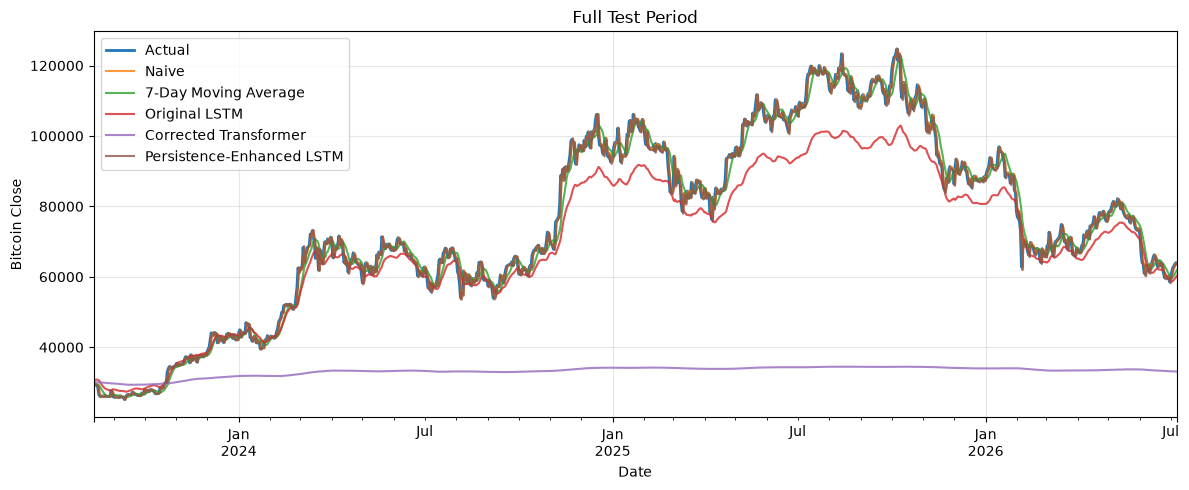

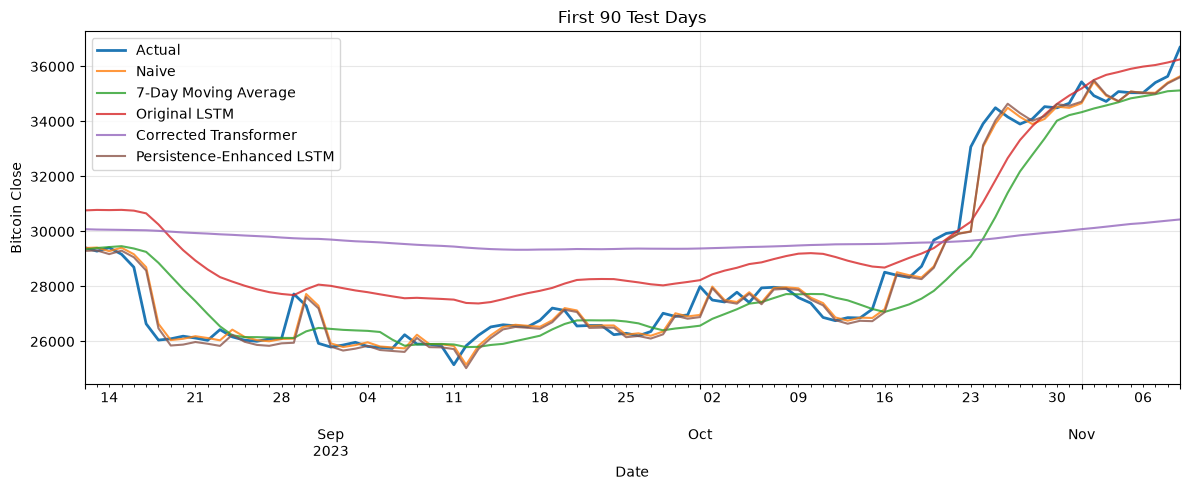

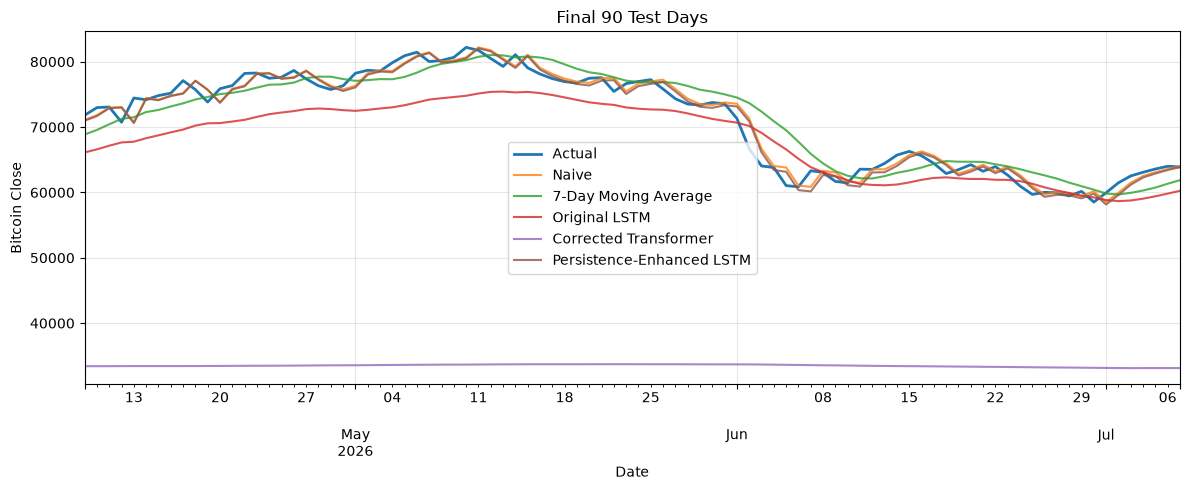

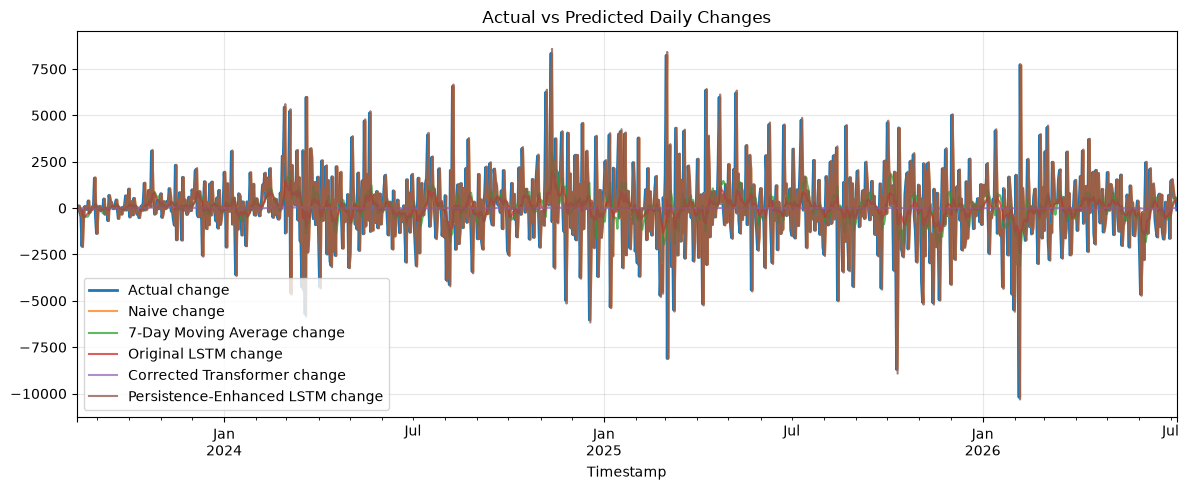

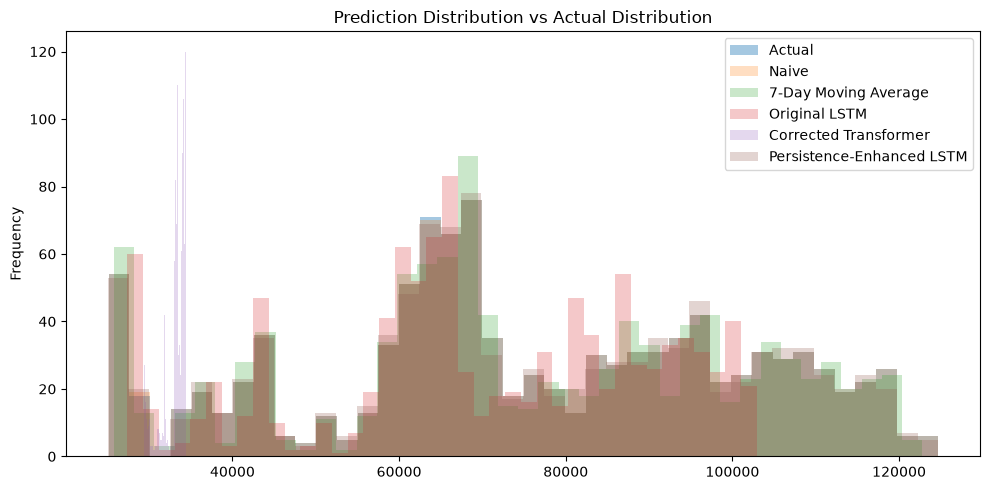

In [16]:
plot_sets = {
    "Full Test Period": y_test.index,
    "First 90 Test Days": y_test.index[:90],
    "Final 90 Test Days": y_test.index[-90:],
}

for title, idx in plot_sets.items():
    fig, ax = plt.subplots(figsize=(12, 5))
    y_test.reindex(idx).plot(ax=ax, label="Actual", linewidth=2)
    for name, forecast in fair_comparison_forecasts.items():
        forecast.reindex(idx).plot(ax=ax, label=name, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Bitcoin Close")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
y_test.diff().plot(ax=ax, label="Actual change", linewidth=2)
for name, forecast in fair_comparison_forecasts.items():
    forecast.diff().plot(ax=ax, label=f"{name} change", alpha=0.75)
ax.set_title("Actual vs Predicted Daily Changes")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
y_test.plot(kind="hist", bins=40, alpha=0.4, ax=ax, label="Actual")
for name, forecast in fair_comparison_forecasts.items():
    forecast.plot(kind="hist", bins=40, alpha=0.25, ax=ax, label=name)
ax.set_title("Prediction Distribution vs Actual Distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Final Diagnosis

In [17]:
diagnosis = pd.DataFrame(
    {
        "Audit Area": [
            "Implementation validity",
            "Forecasting-protocol validity",
            "Model collapse",
            "Over-smoothing",
            "Range compression",
            "Data leakage",
            "Target misalignment",
            "Scaling extrapolation",
        ],
        "Evidence to Review": [
            "Model summaries, linear output activations, shape checks, alignment checks.",
            "Protocol A and Protocol B metrics are reported separately.",
            "Prediction uniqueness, prediction std, and constant-prediction checks.",
            "Prediction daily-change std versus actual daily-change std.",
            "Prediction min/max/std versus actual min/max/std.",
            "Naive and moving-average checks use only prior actual observations; Protocol B forbids test actual feedback.",
            "Sequence maps confirm input window ending on t predicts t+1.",
            "Scaler is fit on train only; test scaled min/max shows extrapolation beyond training range.",
        ],
        "Pass Criteria": [
            "All checks pass or failures are explicitly documented.",
            "No cross-protocol ranking is presented as a single fair leaderboard.",
            "Predictions are not constant except intentionally constant baseline.",
            "Neural change variance is not near zero relative to actual changes.",
            "Forecast range is not implausibly compressed without explanation.",
            "No forecast uses target-day information.",
            "All target dates are exactly one day after window end for one-step models.",
            "Inverse scaling roundtrip passes and extrapolation is acknowledged.",
        ],
    }
)
diagnosis

,Audit Area,Evidence to Review,Pass Criteria
0,Implementation validity,"Model summaries, linear output activations, sh...",All checks pass or failures are explicitly doc...
1,Forecasting-protocol validity,Protocol A and Protocol B metrics are reported...,No cross-protocol ranking is presented as a si...
2,Model collapse,"Prediction uniqueness, prediction std, and con...",Predictions are not constant except intentiona...
3,Over-smoothing,Prediction daily-change std versus actual dail...,Neural change variance is not near zero relati...
4,Range compression,Prediction min/max/std versus actual min/max/std.,Forecast range is not implausibly compressed w...
5,Data leakage,Naive and moving-average checks use only prior...,No forecast uses target-day information.
6,Target misalignment,Sequence maps confirm input window ending on t...,All target dates are exactly one day after win...
7,Scaling extrapolation,Scaler is fit on train only; test scaled min/m...,Inverse scaling roundtrip passes and extrapola...


Final reporting guidance:

- Do not claim that advanced models should automatically beat Naive.
- Treat Naive outperformance as plausible for noisy Bitcoin close prices unless the audit finds leakage, misalignment, or protocol inconsistency.
- Do not use these models in the trustworthiness ranking until this notebook has been run and the diagnosis table is reviewed.
- If neural forecasts remain flat after alignment and scaling checks pass, the likely diagnosis is model/target mismatch or over-smoothing from raw price-level modelling rather than a simple implementation error.